### SMS Span Classifier
- This project focuses on building a machine learning model that detects whether a text message is spam or not(ham).

In [10]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

#wordcloud is a picture made up of words where the size of the each word
#shows how frequently it appears in the dataset.
#The bigger the word appears in the cloud the more often that word is used.
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from nltk.corpus import stopwords

#it is to generate root word
from nltk.stem import PorterStemmer

In [11]:
#stopwords are the words that commonly occur in the sentence or document that has no
# or very little semantic value to text analysis.
# Tasks that benefits from removing stopword: Text classification, sentiment analysis
# Tasks that require preserving stopwords: Machine translation, text summarization, question-answering systems etc.
nltk.download('stopwords')

sns.set_theme(style='whitegrid')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Data Exploration

In [12]:
df = pd.read_csv('spam.csv', encoding='latin-1', header=0)

#since the file contains 5 columns and only first 2 columns matter as 3-5 columns are mostly empty metadata.
df = df.iloc[:, :2]

df.columns = ['label', 'text']

print(df.shape)
print(df.columns)
print(df.head(10))

print(df['label'].unique())

(5572, 2)
Index(['label', 'text'], dtype='str')
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
5  spam  FreeMsg Hey there darling it's been 3 week's n...
6   ham  Even my brother is not like to speak with me. ...
7   ham  As per your request 'Melle Melle (Oru Minnamin...
8  spam  WINNER!! As a valued network customer you have...
9  spam  Had your mobile 11 months or more? U R entitle...
<StringArray>
['ham', 'spam']
Length: 2, dtype: str


In [13]:
df['label'] = df['label'].map({
    "ham": 0,
    "spam": 1
})

counts=df['label'].value_counts()
print(counts)

label
0    4825
1     747
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22968\2539169578.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


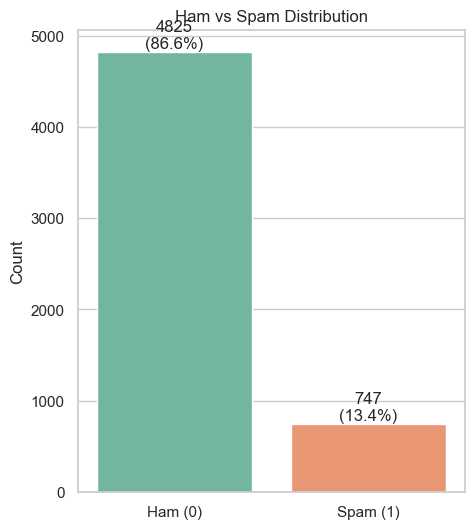

In [14]:
counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(5, 6))

# Barplot
bars = sns.barplot(
    x=['Ham (0)', 'Spam (1)'],
    y=counts.values,
    palette='Set2',
   
)

# Total count
total = counts.sum()

# Add annotations
for bar in bars.patches:
    count = int(bar.get_height())
    percentage = (count / total) * 100

    bars.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
    )

plt.ylabel("Count")
plt.title("Ham vs Spam Distribution")

plt.show()

From above bar plot observation:
The dataset is imbalanced because ham messages are significantly more than spam messages.

#### Text Preprocessing

In [15]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()

    cleaned_words = [stemmer.stem(word) for word in words if word not in stop_words]

    return ' '.join(cleaned_words)

print("clean_text() defined.")

clean_text() defined.


Message 1 
Label: HAM
Original Message: 
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned Messsage: 
go jurong point crazi avail bugi n great world la e buffet cine got amor wat
Message 2 
Label: HAM
Original Message: 
Ok lar... Joking wif u oni...
Cleaned Messsage: 
ok lar joke wif u oni
Message 3 
Label: SPAM
Original Message: 
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned Messsage: 
free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over
Message 4 
Label: HAM
Original Message: 
U dun say so early hor... U c already then say...
Cleaned Messsage: 
u dun say earli hor u c alreadi say
Message 5 
Label: HAM
Original Message: 
Nah I don't think he goes to usf, he lives around here though
Cleaned Messsage: 
nah dont think goe usf live around though


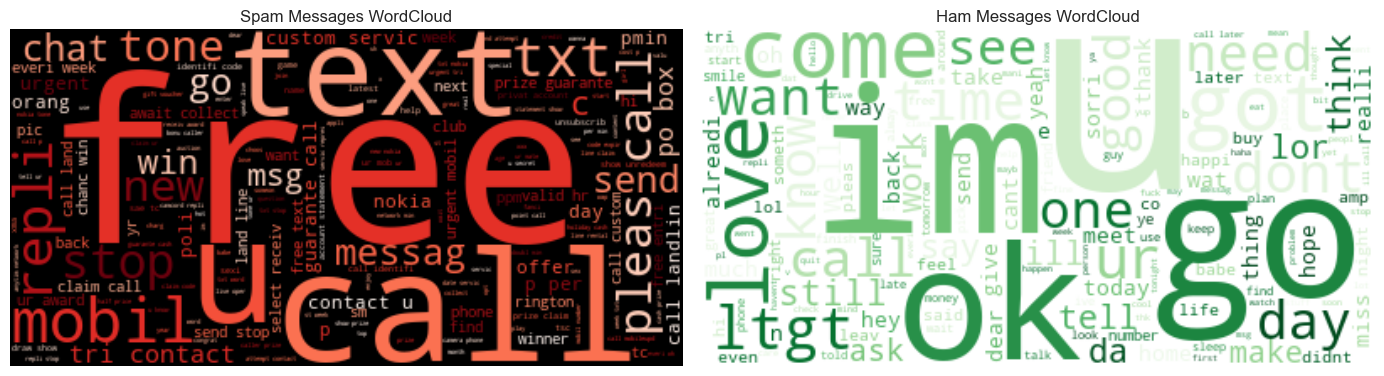

In [18]:
df['clean_text'] = df['text'].apply(clean_text)

for i in range(5):
    label = "HAM" if df['label'][i] == 0 else 'SPAM'

    print(f"Message {i+1} ")
    print(f"Label: {label}")
    
    print("Original Message: ")
    print(df['text'][i])

    print("Cleaned Messsage: ")
    print(df['clean_text'][i])

#combining all the spam and ham messages
spam_text = ' '.join(df[df['label']==1]['clean_text'])

ham_text = ' '.join(df[df['label']==0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

spam_wc = WordCloud(background_color='black', colormap='Reds').generate(spam_text)

axes[0].imshow(spam_wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Spam Messages WordCloud')

ham_wc = WordCloud(background_color='white', colormap='Greens').generate(ham_text)

axes[1].imshow(ham_wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Ham Messages WordCloud')

plt.tight_layout()
plt.show()

From above wordcloud:
We can see that spam messages frequently contain promotional and urgent words such as free, win, call, while ham messages contain more casual conversational words used in everyday communication.

#### Feature Engineering and Model Training

In [22]:
tfidf = TfidfVectorizer(max_features=5000)

#converting into array
y = df['label'].values

print("Total number of messages: ", len(y))
print("Number of spam messages: ", y.sum())
print("Number of ham messages: ", len(y) - y.sum())

Total number of messages:  5572
Number of spam messages:  747
Number of ham messages:  4825


In [25]:
X = df['clean_text']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
X_train_text = tfidf.fit_transform(X_train)
X_test_text = tfidf.transform(X_test)

In [29]:
print("Shape of training sets: ", X_train_text.shape)
print('Shape of testing sets: ', X_test_text)

Shape of training sets:  (4457, 5000)
Shape of testing sets:  <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8094 stored elements and shape (1115, 5000)>
  Coords	Values
  (0, 959)	0.16861901331022472
  (0, 1186)	0.32445338152181824
  (0, 1645)	0.16776687851944755
  (0, 1725)	0.223877014615129
  (0, 1933)	0.16734744567228124
  (0, 2443)	0.28350892814977857
  (0, 2584)	0.19376694139198367
  (0, 2925)	0.35250844956965904
  (0, 3144)	0.2002742226308919
  (0, 3151)	0.163756183396429
  (0, 3763)	0.4195586667350393
  (0, 3887)	0.2080319437027834
  (0, 4171)	0.33609728680649187
  (0, 4499)	0.2148453000065523
  (0, 4617)	0.1829325612430893
  (0, 4896)	0.19754454302601532
  (1, 467)	0.31965880532819796
  (1, 923)	0.47107865726707837
  (1, 4606)	0.8221332901930173
  (2, 1460)	0.6563221928676012
  (2, 1706)	0.5731910531963557
  (2, 2654)	0.4906049283131141
  (3, 467)	0.3415590490338109
  (3, 539)	0.551459145653226
  (3, 672)	0.5174790814313558
  :	:
  (1111, 2579)	0.285545356195085

##### Training Naive Bayes Model

In [30]:
nb = MultinomialNB()
nb.fit(X_train_text, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [32]:
y_pred = nb.predict(X_test_text)

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print(round(accuracy, 4))

0.9641


#### Training Logistic Regression

In [37]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_text, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [39]:
lr_acc = lr.score(X_test_text, y_test)
print(lr_acc)

0.9659192825112107


In [40]:
best_model = lr
y_pred = best_model.predict(X_test_text)

print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.75      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115

